## Forecast Findings

### Model Summary
- Method: Linear regression on 18 months of monthly hire data
- R² value: [paste your R² here] — explains how well the trend fits
- Trend direction: [increasing / decreasing / flat] at [X] hires/month

### Limitations
- Linear regression assumes the historical trend continues unchanged
- Monthly hire counts are small (avg ~6/month) — high variance
- External factors (budget freeze, market conditions) are not modelled
- This is a planning tool, not a prediction — it answers "given current
  pace, what happens?" not "what will definitely happen?"

Monthly pipeline summary:
  month_dt  applications  hires
2023-01-01            83    0.0
2023-02-01           103    2.0
2023-03-01           117    9.0
2023-04-01            98    5.0
2023-05-01           110    7.0
2023-06-01           102    6.0
2023-07-01            84    5.0
2023-08-01            95    6.0
2023-09-01           102    7.0
2023-10-01           107    6.0
2023-11-01           102    3.0
2023-12-01           100    5.0
2024-01-01           116   10.0
2024-02-01            81   11.0
2024-03-01            99    4.0
2024-04-01           105    8.0
2024-05-01           112    6.0
2024-06-01            84    0.0

Avg hires/month: 5.6

Model R²: 0.027
Monthly hire trend: +0.09 hires/month

── Q3 Assessment ───────────────────────────────────────
Q3 target: 18 hires
Projected: 19.6 hires
✅ Q3 target on track

6-month projection:
  month_dt  predicted_hires  cumulative_hires
2024-07-01              6.4               6.4
2024-08-01              6.5              13.0
2024-09-0

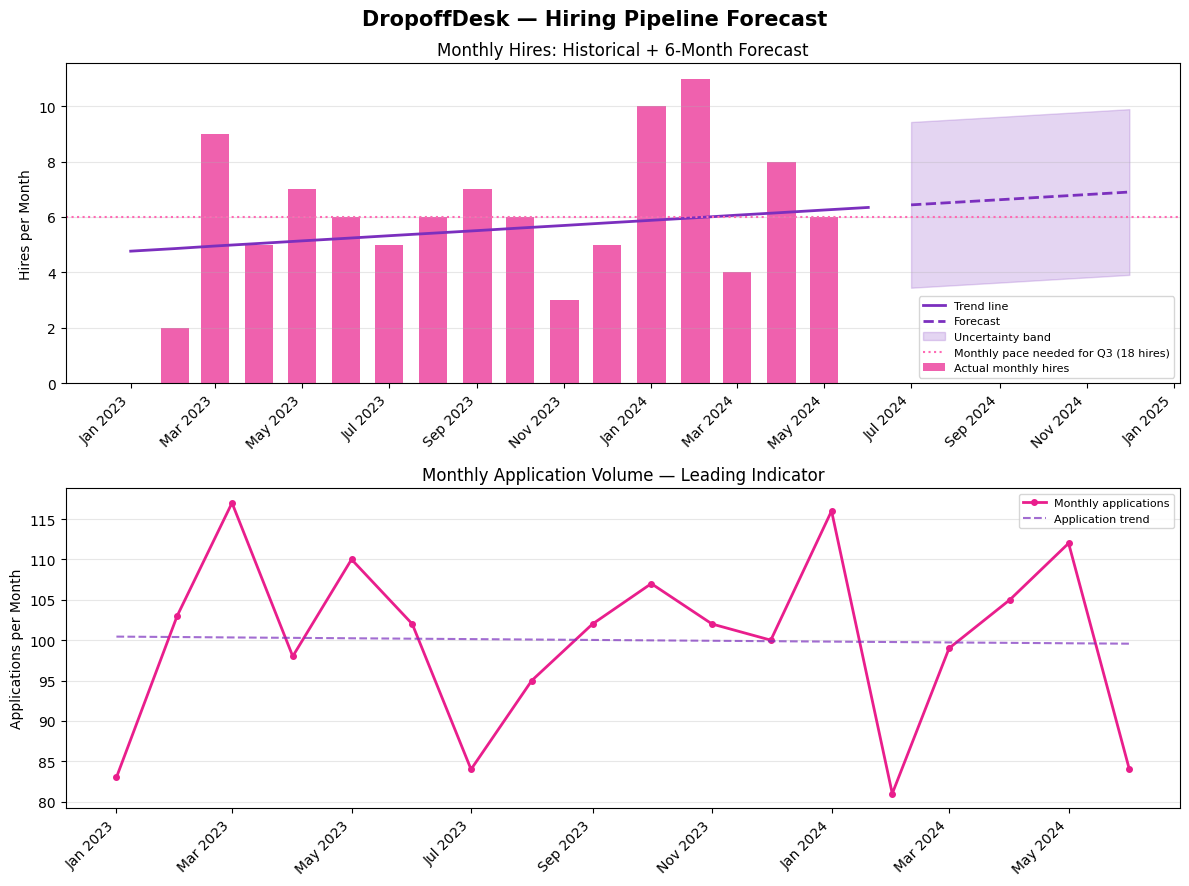

✅ Chart saved to docs/forecast_chart.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ── LOAD DATA ─────────────────────────────────────────────────
candidates = pd.read_csv('../data/clean/candidates_clean.csv', parse_dates=['application_date'])
offers     = pd.read_csv('../data/clean/offers_clean.csv', parse_dates=['offer_date'])

candidates['month'] = candidates['application_date'].dt.to_period('M')
monthly_apps = candidates.groupby('month').size().reset_index(name='applications')

accepted = offers[offers['accepted'] == True].copy()
accepted['month'] = accepted['offer_date'].dt.to_period('M')
monthly_hires = accepted.groupby('month').size().reset_index(name='hires')

monthly = monthly_apps.merge(monthly_hires, on='month', how='left')
monthly['hires'] = monthly['hires'].fillna(0)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()
monthly['month_num'] = range(len(monthly))

print("Monthly pipeline summary:")
print(monthly[['month_dt', 'applications', 'hires']].to_string(index=False))
print(f"\nAvg hires/month: {monthly['hires'].mean():.1f}")

# ── FIT REGRESSION ────────────────────────────────────────────
X = monthly[['month_num']]
y = monthly['hires']

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)
print(f"\nModel R²: {r_squared:.3f}")
print(f"Monthly hire trend: {model.coef_[0]:+.2f} hires/month")

last_month_num = monthly['month_num'].max()
last_month_dt  = monthly['month_dt'].max()

future_months = pd.DataFrame({
    'month_num': range(last_month_num + 1, last_month_num + 7),
    'month_dt':  [last_month_dt + pd.DateOffset(months=i) for i in range(1, 7)]
})
future_months['predicted_hires'] = model.predict(future_months[['month_num']]).clip(min=0)
future_months['cumulative_hires'] = future_months['predicted_hires'].cumsum()

Q3_TARGET = 18
projected_q3 = future_months['predicted_hires'].iloc[0:3].sum()
shortfall = Q3_TARGET - projected_q3

print(f"\n── Q3 Assessment ───────────────────────────────────────")
print(f"Q3 target: {Q3_TARGET} hires")
print(f"Projected: {projected_q3:.1f} hires")
if shortfall > 0:
    print(f"⚠️  Shortfall: {shortfall:.1f} hires — Q3 target will NOT be met at current pace")
else:
    print(f"✅ Q3 target on track")

print(f"\n6-month projection:")
print(future_months[['month_dt','predicted_hires','cumulative_hires']].round(1).to_string(index=False))

# ── FORECAST CHART (pink & purple theme) ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
fig.suptitle('DropoffDesk — Hiring Pipeline Forecast', fontsize=15, fontweight='bold')

ax1 = axes[0]
ax1.bar(monthly['month_dt'], monthly['hires'],
        color='#E91E8C', alpha=0.7, label='Actual monthly hires', width=20)

trend_y = model.predict(monthly[['month_num']])
ax1.plot(monthly['month_dt'], trend_y,
         color='#7B2FBE', linewidth=2, label='Trend line')
ax1.plot(future_months['month_dt'], future_months['predicted_hires'],
         color='#7B2FBE', linewidth=2, linestyle='--', label='Forecast')

residuals = y - trend_y
std_err = residuals.std()
ax1.fill_between(future_months['month_dt'],
                 future_months['predicted_hires'] - std_err,
                 future_months['predicted_hires'] + std_err,
                 alpha=0.2, color='#7B2FBE', label='Uncertainty band')

ax1.axhline(y=Q3_TARGET/3, color='#FF69B4', linestyle=':', linewidth=1.5,
            label=f'Monthly pace needed for Q3 ({Q3_TARGET} hires)')
ax1.set_title('Monthly Hires: Historical + 6-Month Forecast')
ax1.set_ylabel('Hires per Month')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(monthly['month_dt'], monthly['applications'],
         color='#E91E8C', linewidth=2, marker='o', markersize=4,
         label='Monthly applications')
model2 = LinearRegression().fit(X, monthly['applications'])
ax2.plot(monthly['month_dt'], model2.predict(X),
         color='#7B2FBE', linewidth=1.5, linestyle='--', alpha=0.7,
         label='Application trend')
ax2.set_title('Monthly Application Volume — Leading Indicator')
ax2.set_ylabel('Applications per Month')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/forecast_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to docs/forecast_chart.png")